In [23]:
import os
import pandas as pd
import numpy as np
from PIL import Image
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
# ==========================================
# 1. Custom Dataset Loader (Updated for DataFrames)
# ==========================================
class RetinopathyDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        # We now pass a DataFrame directly so we can split it beforehand
        self.labels_df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.labels_df)

    def __getitem__(self, idx):
        img_name = str(self.labels_df.iloc[idx]['image'])
        if not img_name.endswith('.jpeg'):
            img_name += '.jpeg'
            
        img_path = os.path.join(self.image_dir, img_name)
        image = Image.open(img_path).convert('RGB')
        
        if self.transform:
            image = self.transform(image)
            
        label = int(self.labels_df.iloc[idx]['level'])
        return image, label

In [25]:
# ==========================================
# 2. Data Preparation and Splitting
# ==========================================
LABELS_PATH = 'trainLabels.csv' 
IMAGE_DIR = 'train_preprocessed' 

print("Loading and filtering dataset...")
# Load the full CSV
if LABELS_PATH.endswith('.csv'):
    full_df = pd.read_csv(LABELS_PATH)
else:
    full_df = pd.read_excel(LABELS_PATH)

# Filter out images that don't exist in the folder
def check_image_exists(img_name):
    img_str = str(img_name)
    if not img_str.endswith('.jpeg'):
        img_str += '.jpeg'
    return os.path.exists(os.path.join(IMAGE_DIR, img_str))

mask = full_df['image'].apply(check_image_exists)
filtered_df = full_df[mask].reset_index(drop=True)

if len(filtered_df) == 0:
    raise ValueError(f"No matching images found in '{IMAGE_DIR}'. Please check your paths.")

print(f"Found {len(filtered_df)} valid images. Splitting data 70/30...")

# Split the dataframe 70/30. 
# stratify=filtered_df['level'] ensures the ratio of 0-4 classes remains the same in both sets.
train_df, test_df = train_test_split(filtered_df, test_size=0.30, random_state=42, stratify=filtered_df['level'])

Loading and filtering dataset...
Found 8408 valid images. Splitting data 70/30...


In [26]:
# ==========================================
# 3. Transforms and DataLoaders
# ==========================================
# Training gets data augmentation (flips, rotations) to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Testing ONLY gets resized and normalized. No random rotations or flips!
test_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = RetinopathyDataset(dataframe=train_df, image_dir=IMAGE_DIR, transform=train_transform)
test_dataset = RetinopathyDataset(dataframe=test_df, image_dir=IMAGE_DIR, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
# No need to shuffle test data
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False) 

print(f"Training set: {len(train_dataset)} images")
print(f"Testing set: {len(test_dataset)} images")

Training set: 5885 images
Testing set: 2523 images


In [27]:
# ==========================================
# 4. Model Setup
# ==========================================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 5) 
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

Using device: cuda


In [28]:
from tqdm import tqdm  # Add this to your imports at the top

# ==========================================
# 5. Training Loop
# ==========================================
num_epochs = 32
train_losses = []
train_accuracies = []

print("\n--- Starting Training ---")
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    # Wrap train_loader with tqdm for a progress bar!
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{num_epochs}', leave=False)
    
    for images, labels in progress_bar:
        images, labels = images.to(device), labels.to(device)
        
        outputs = model(images)
        loss = criterion(outputs, labels)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        
        # Update the progress bar with the current loss
        progress_bar.set_postfix({'loss': loss.item()})
        
    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * (correct / total)
    
    train_losses.append(epoch_loss)
    train_accuracies.append(epoch_acc)
    
    # Exact float numbers and exact correct/total counts
    print(f'Epoch [{epoch+1}/{num_epochs}] Completed - Loss: {epoch_loss}, Accuracy: {epoch_acc}% ({correct}/{total})')


--- Starting Training ---


Epoch [1/32] Completed - Loss: 0.8173389762801968, Accuracy: 73.47493627867459% (4324/5885)


Epoch [2/32] Completed - Loss: 0.6899738820755611, Accuracy: 76.7714528462192% (4518/5885)


Epoch [3/32] Completed - Loss: 0.6365004463283264, Accuracy: 77.70603228547154% (4573/5885)


Epoch [4/32] Completed - Loss: 0.5868831070787881, Accuracy: 80.30586236193713% (4726/5885)


...

Epoch [28/32] Completed - Loss: 0.05868793321101491, Accuracy: 97.96091758708582% (5765/5885)


Epoch [29/32] Completed - Loss: 0.06739274162954763, Accuracy: 97.67204757858964% (5748/5885)


Epoch [30/32] Completed - Loss: 0.06263265347028525, Accuracy: 97.7909940526763% (5755/5885)


Epoch [31/32] Completed - Loss: 0.06953135074044163, Accuracy: 97.72302463891249% (5751/5885)


Epoch [32/32] Completed - Loss: 0.05761289126293496, Accuracy: 98.13084112149532% (5775/5885)


In [29]:
# ==========================================
# 6. Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data ---")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data ---



Overall Test Accuracy: 79.03289734443123% (1994/2523)
Quadratic Weighted Kappa: 0.6063612993353544

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.97      0.89      1845
           1       0.50      0.05      0.08       177
           2       0.60      0.37      0.46       385
           3       0.65      0.47      0.54        66
           4       0.64      0.32      0.43        50

    accuracy                           0.79      2523
   macro avg       0.64      0.44      0.48      2523
weighted avg       0.75      0.79      0.75      2523


Plots saved as 'training_metrics.png' and 'confusion_matrix.png'


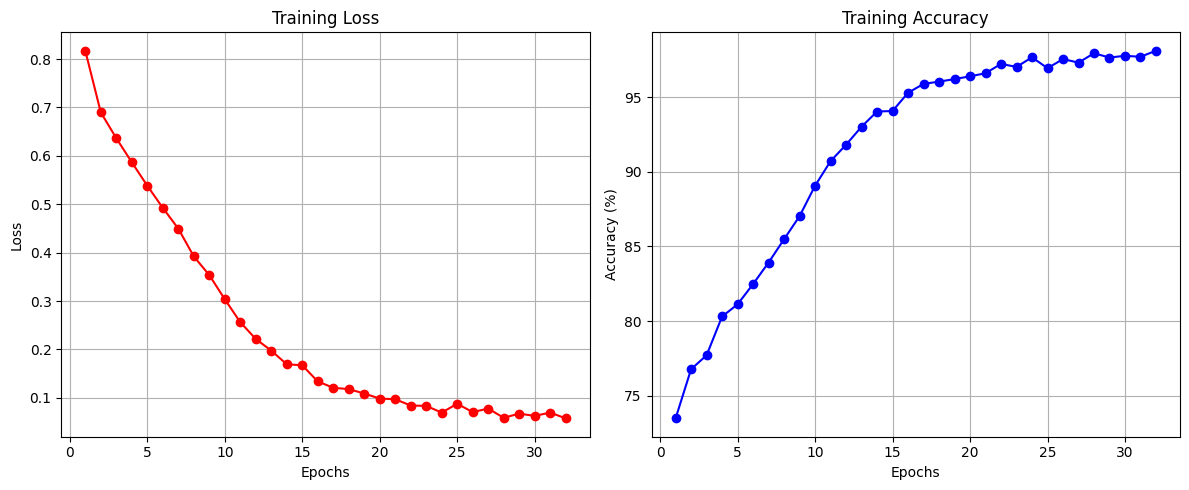

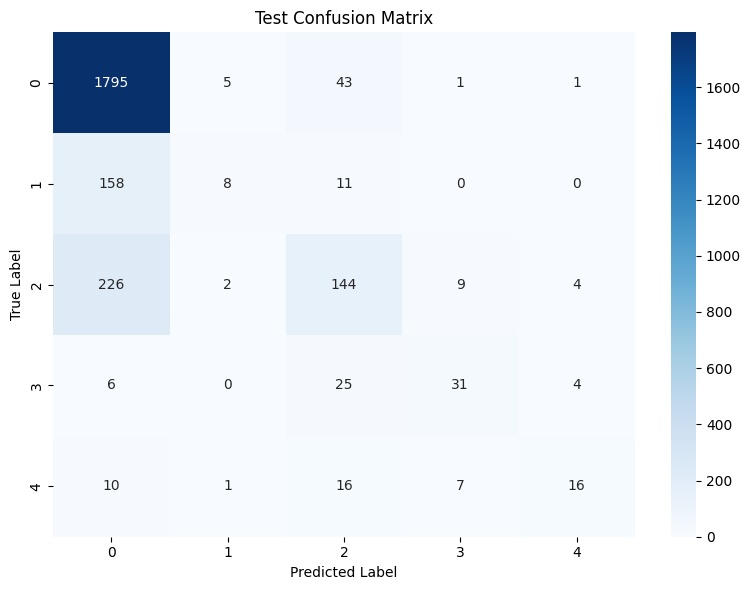

In [30]:
# ==========================================
# 7. Metrics & Visualization
# ==========================================
# Calculate exact test accuracy
test_correct = sum(1 for p, l in zip(all_preds, all_labels) if p == l)
test_total = len(all_labels)
test_acc = 100 * (test_correct / test_total)

print(f"\nOverall Test Accuracy: {test_acc}% ({test_correct}/{test_total})")

kappa = cohen_kappa_score(all_labels, all_preds, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa}")

print("\nClassification Report:")
print(classification_report(all_labels, all_preds, zero_division=0))

# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels, all_preds)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

print("\nPlots saved as 'training_metrics.png' and 'confusion_matrix.png'")
plt.show()

In [32]:
# ==========================================
# 8.a. Evaluation Loop (Testing)
# ==========================================
print("\n--- Starting Evaluation on 30% Test Data ---")
model.eval()
all_preds_x = []
all_labels_x = []

with torch.no_grad():
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)
        
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        all_preds_x.extend(predicted.cpu().numpy())
        all_labels_x.extend(labels.cpu().numpy())


--- Starting Evaluation on 30% Test Data ---



Overall Training Accuracy: 98.16482582837723% (5777/5885)
Quadratic Weighted Kappa: 0.9801224503433258

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99      4305
           1       0.99      0.83      0.90       411
           2       0.99      0.97      0.98       898
           3       0.94      0.99      0.97       155
           4       1.00      0.97      0.99       116

    accuracy                           0.98      5885
   macro avg       0.98      0.95      0.97      5885
weighted avg       0.98      0.98      0.98      5885


Plots saved as 'training_metrics.png' and 'confusion_matrix.png'


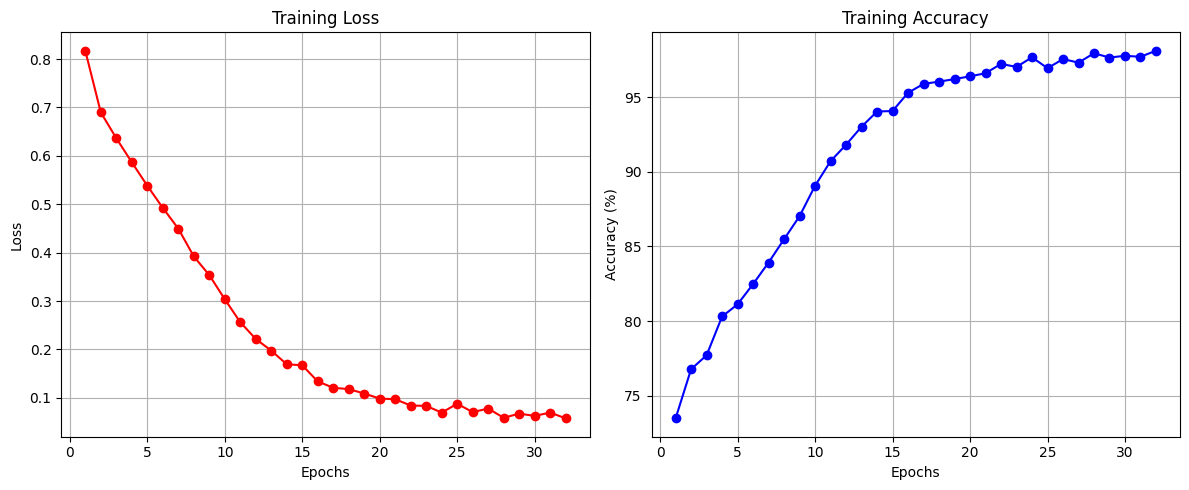

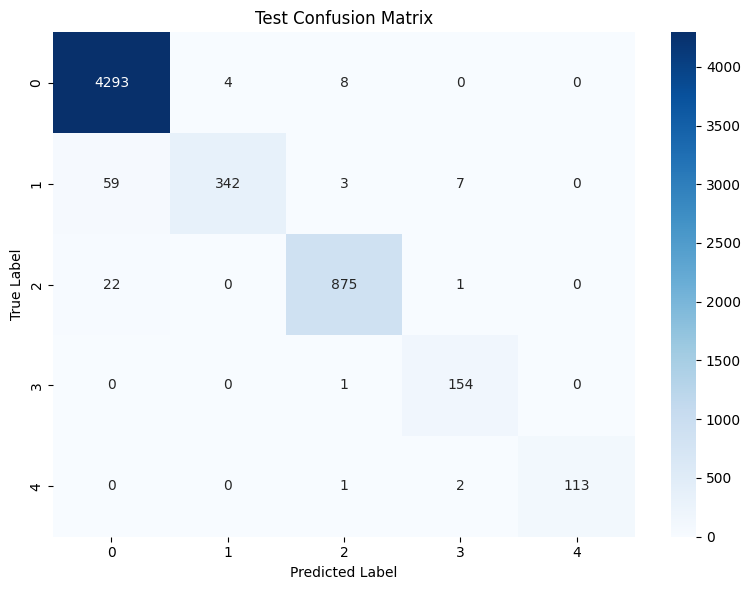

In [34]:
# ==========================================
# 8. Metrics & Visualization
# ==========================================
# Calculate exact test accuracy
train_correct = sum(1 for p, l in zip(all_preds_x, all_labels_x) if p == l)
train_total = len(all_labels_x)
train_acc = 100 * (train_correct / train_total)

print(f"\nOverall Training Accuracy: {train_acc}% ({train_correct}/{train_total})")

kappa = cohen_kappa_score(all_labels_x, all_preds_x, weights='quadratic')
print(f"Quadratic Weighted Kappa: {kappa}")

print("\nClassification Report:")
print(classification_report(all_labels_x, all_preds_x, zero_division=0))
# Plot Training Metrics
plt.figure(figsize=(12, 5))
epochs_range = range(1, num_epochs + 1)

plt.subplot(1, 2, 1)
plt.plot(epochs_range, train_losses, label='Training Loss', color='red', marker='o')
plt.title('Training Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, train_accuracies, label='Training Accuracy', color='blue', marker='o')
plt.title('Training Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.grid(True)

plt.tight_layout()
plt.savefig('training_metrics.png')

# Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(all_labels_x, all_preds_x)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=[0,1,2,3,4], yticklabels=[0,1,2,3,4])
plt.title('Test Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png')

print("\nPlots saved as 'training_metrics.png' and 'confusion_matrix.png'")
plt.show()